In [1]:
!pip install simpleitk

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [34]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import numpy as np

from scipy.ndimage import label, find_objects
from matplotlib.colors import BoundaryNorm
from ipywidgets import interact
from math import ceil

def find_and_plot_nodules(path, size_threshold=0):
  # Load the image
  nodule_nnrd = sitk.ReadImage(path)
  spacing = nodule_nnrd.GetSpacing()
  voxelvolume = sitk.GetArrayFromImage(nodule_nnrd)

  # Segment the image using scipy.ndimage.label
  label_mask, num_features = label(voxelvolume)

  # Get a list of nodule slices
  object_slices = find_objects(label_mask)

  # Plot each nodule individually
  ncols = 4
  fig, axes = plt.subplots(ceil(num_features / ncols), ncols, dpi=150, subplot_kw={'projection': '3d'})
  axes = axes.flatten()

  for i, (ax, slc) in enumerate(zip(axes, object_slices)):
    # Print size in each direction
    sizeX = (slc[2].stop-slc[2].start) * spacing[0]
    sizeY = (slc[1].stop-slc[1].start) * spacing[1]
    sizeZ = (slc[0].stop-slc[0].start) * spacing[2]
    size_min = np.min([sizeX, sizeY, sizeZ])
    size_str =  f'SIZE:\tmin = {size_min:5.2f}\t(Z, Y, X) = ({sizeX:5.2f}, {sizeY:5.2f}, {sizeZ:5.2f})'
    print(size_str)

    if size_min < size_threshold:
      ax.set_visible(False)

    ax.voxels(
        filled=label_mask[slc[0], slc[1], slc[2]],
        facecolors=plt.cm.tab20(i-1)
    )
    ax.axis('off')
    title = f'${slc[0].start}\\leq z < {slc[0].stop}$'
    ax.set_title(title)

  # Erase unused axes
  while i < len(axes)-1:
    i += 1
    axes[i].set_visible(False)

  # Plot with a slider (this is janky, you can also just use FIJI)
  N, h, w = label_mask.shape

  cmap = plt.get_cmap('tab20', num_features)
  cmap.set_under('black')
  norm = BoundaryNorm(np.arange(-0.5, num_features, 1), cmap.N)

  def update(frame):
      im = plt.imshow(label_mask[frame]-1, cmap=cmap, norm=norm)
      plt.colorbar(im, ticks=np.arange(0, num_features))
      plt.axis('off')
      plt.title(f'Frame {frame}')
      plt.show()

  return interact(update, frame=(0, N-1))

SIZE:	min =  5.27	(Z, Y, X) = ( 7.03,  5.27,  6.00)
SIZE:	min =  2.93	(Z, Y, X) = ( 4.69,  2.93,  4.00)
SIZE:	min = 12.00	(Z, Y, X) = (14.06, 13.48, 12.00)
SIZE:	min =  3.52	(Z, Y, X) = ( 3.52,  4.10,  4.00)
SIZE:	min =  3.52	(Z, Y, X) = ( 3.52,  4.10,  4.00)
SIZE:	min =  4.00	(Z, Y, X) = ( 4.10,  4.69,  4.00)
SIZE:	min =  2.00	(Z, Y, X) = ( 3.52,  2.93,  2.00)
SIZE:	min =  7.03	(Z, Y, X) = (11.13,  7.03, 10.00)
SIZE:	min =  2.00	(Z, Y, X) = ( 3.52,  2.93,  2.00)
SIZE:	min =  4.00	(Z, Y, X) = ( 4.69,  4.69,  4.00)
SIZE:	min =  8.00	(Z, Y, X) = ( 9.38,  8.79,  8.00)


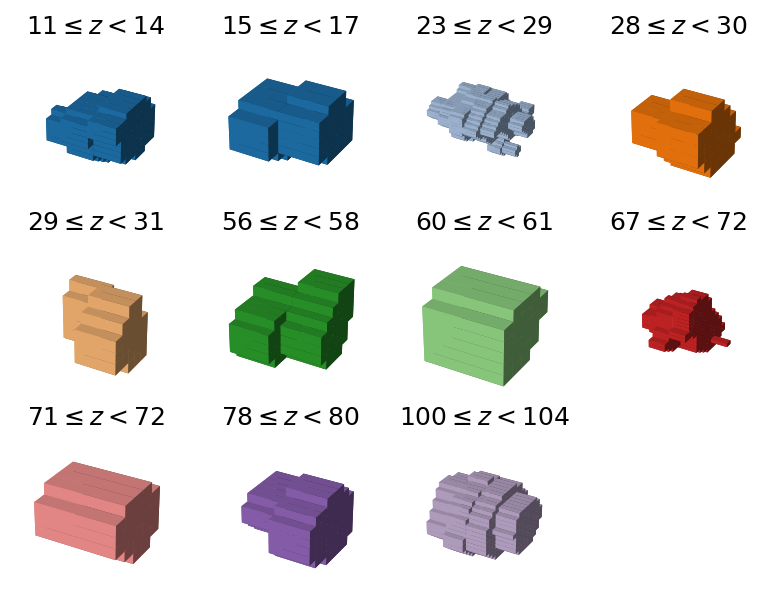

interactive(children=(IntSlider(value=71, description='frame', max=143), Output()), _dom_classes=('widget-inte…

In [32]:
find_and_plot_nodules('/content/gdrive/MyDrive/Radiomics/nodules0.nrrd');

SIZE:	min =  2.73	(Z, Y, X) = ( 3.28,  2.73,  4.00)
SIZE:	min =  4.00	(Z, Y, X) = ( 6.56,  4.38,  4.00)
SIZE:	min =  6.00	(Z, Y, X) = ( 7.11,  6.56,  6.00)
SIZE:	min =  2.73	(Z, Y, X) = ( 2.73,  3.28,  4.00)
SIZE:	min = 13.67	(Z, Y, X) = (13.67, 14.22, 14.00)
SIZE:	min =  4.92	(Z, Y, X) = ( 4.92,  5.47,  8.00)
SIZE:	min =  7.66	(Z, Y, X) = ( 9.84,  7.66,  8.00)
SIZE:	min =  8.00	(Z, Y, X) = ( 8.75,  8.20,  8.00)


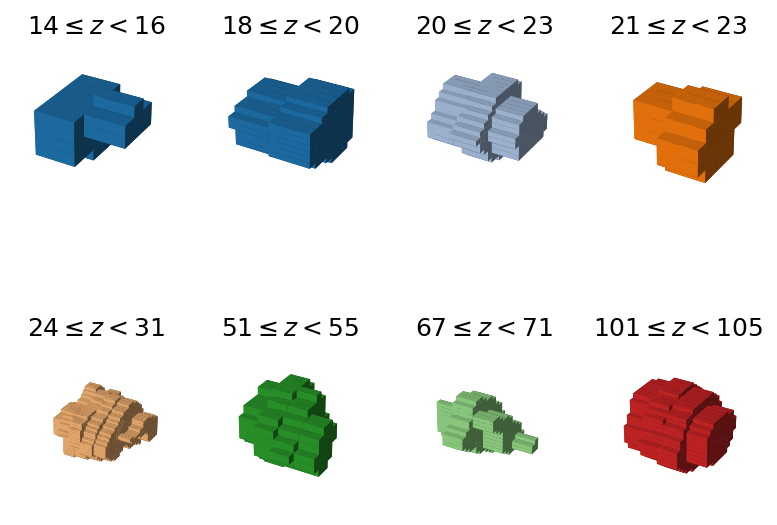

interactive(children=(IntSlider(value=72, description='frame', max=145), Output()), _dom_classes=('widget-inte…

In [33]:
find_and_plot_nodules('/content/gdrive/MyDrive/Radiomics/nodules1.nrrd');

# With size thresholding, if you want

SIZE:	min =  5.27	(Z, Y, X) = ( 7.03,  5.27,  6.00)
SIZE:	min =  2.93	(Z, Y, X) = ( 4.69,  2.93,  4.00)
SIZE:	min = 12.00	(Z, Y, X) = (14.06, 13.48, 12.00)
SIZE:	min =  3.52	(Z, Y, X) = ( 3.52,  4.10,  4.00)
SIZE:	min =  3.52	(Z, Y, X) = ( 3.52,  4.10,  4.00)
SIZE:	min =  4.00	(Z, Y, X) = ( 4.10,  4.69,  4.00)
SIZE:	min =  2.00	(Z, Y, X) = ( 3.52,  2.93,  2.00)
SIZE:	min =  7.03	(Z, Y, X) = (11.13,  7.03, 10.00)
SIZE:	min =  2.00	(Z, Y, X) = ( 3.52,  2.93,  2.00)
SIZE:	min =  4.00	(Z, Y, X) = ( 4.69,  4.69,  4.00)
SIZE:	min =  8.00	(Z, Y, X) = ( 9.38,  8.79,  8.00)


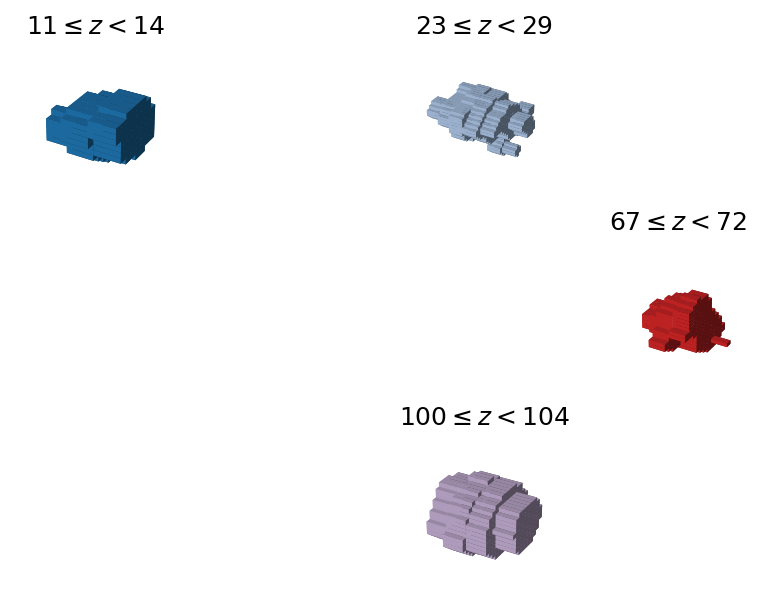

interactive(children=(IntSlider(value=71, description='frame', max=143), Output()), _dom_classes=('widget-inte…

In [35]:
# With size thresholding
find_and_plot_nodules('/content/gdrive/MyDrive/Radiomics/nodules0.nrrd', size_threshold=5);

SIZE:	min =  2.73	(Z, Y, X) = ( 3.28,  2.73,  4.00)
SIZE:	min =  4.00	(Z, Y, X) = ( 6.56,  4.38,  4.00)
SIZE:	min =  6.00	(Z, Y, X) = ( 7.11,  6.56,  6.00)
SIZE:	min =  2.73	(Z, Y, X) = ( 2.73,  3.28,  4.00)
SIZE:	min = 13.67	(Z, Y, X) = (13.67, 14.22, 14.00)
SIZE:	min =  4.92	(Z, Y, X) = ( 4.92,  5.47,  8.00)
SIZE:	min =  7.66	(Z, Y, X) = ( 9.84,  7.66,  8.00)
SIZE:	min =  8.00	(Z, Y, X) = ( 8.75,  8.20,  8.00)


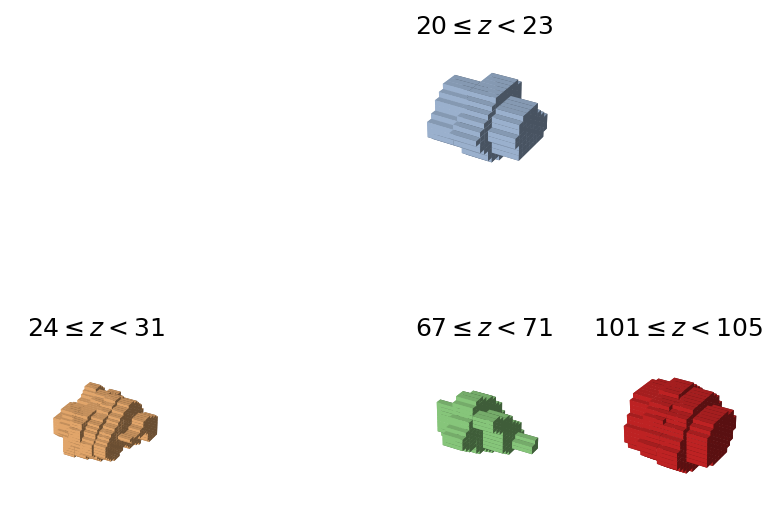

interactive(children=(IntSlider(value=72, description='frame', max=145), Output()), _dom_classes=('widget-inte…

In [36]:
find_and_plot_nodules('/content/gdrive/MyDrive/Radiomics/nodules1.nrrd', size_threshold=5);